# Priority Classifier 

**Nessun prerequisito Colab** — gli embedding vengono calcolati localmente su CPU (o caricati dalla cache se già esistenti).

### Pipeline
1. Carica `dataset_clean.csv` e split temporale
2. Calcola embedding **intfloat/multilingual-e5-base** su CPU (con caching su disco)
3. Feature engineering OHE
4. Tuning C con 3-fold CV
5. Training LinearSVC + valutazione
6. Salvataggio in `modelli/priority_v2/`


---
## STEP 1 — Caricamento dataset e split temporale

In [48]:
import pandas as pd
import numpy as np
import warnings
import time
import os
from pathlib import Path
warnings.filterwarnings('ignore')

# Il kernel VS Code parte dalla cartella notebooks/, non dalla root del progetto.
# os.path.abspath('') restituisce la directory corrente del kernel,
# quindi .parent risale di un livello e otteniamo la root di TicketClassifier/.
BASE_DIR = Path(os.path.abspath('')).parent

DATA_DIR = BASE_DIR / 'data'
EMB_DIR  = BASE_DIR / 'embeddings'
MOD_DIR  = BASE_DIR / 'modelli'

# Lo split e' temporale (non random) per simulare un vero scenario produttivo:
# il modello viene addestrato su dati storici e valutato su dati futuri.
# Uno split random sovrastimerebbe le performance perche' ticket simili
# (stesso cliente, stesso tipo di problema) finirebbero sia in train che in test.
SOGLIA_SPLIT = '2025-11-21'

df = pd.read_csv(DATA_DIR / 'dataset_clean.csv', parse_dates=['data_creazione'])

df_train = df[df['data_creazione'] < SOGLIA_SPLIT].copy()
df_test  = df[df['data_creazione'] >= SOGLIA_SPLIT].copy()

print(f"Dataset totale  : {len(df):,} ticket")
print(f"Train (<{SOGLIA_SPLIT})  : {len(df_train):,} ({len(df_train)/len(df):.2%})")
print(f"Test  (>={SOGLIA_SPLIT}) : {len(df_test):,} ({len(df_test)/len(df):.2%})")
print(f"\nDistribuzione priorita' — train:")
print(df_train['priorita_finale'].value_counts().sort_index())
print(f"\nDistribuzione priorita' — test:")
print(df_test['priorita_finale'].value_counts().sort_index())

Dataset totale  : 61,156 ticket
Train (<2025-11-21)  : 48,813 (79.82%)
Test  (>=2025-11-21) : 12,343 (20.18%)

Distribuzione priorita' — train:
priorita_finale
P1     6799
P2    14322
P3    26409
P4     1283
Name: count, dtype: int64

Distribuzione priorita' — test:
priorita_finale
P1    1582
P2    3415
P3    7087
P4     259
Name: count, dtype: int64


---
## STEP 2 — Calcolo embedding E5 su CPU (con caching su disco)

Il testo viene prefissato con `query: ` come richiesto dal modello **intfloat/multilingual-e5-base**.  
Se i file `.npy` esistono gia' nella cartella `embeddings/` vengono caricati direttamente,
altrimenti vengono calcolati su CPU e salvati per le run successive.

In [49]:
from sentence_transformers import SentenceTransformer

MODEL_NAME     = 'intfloat/multilingual-e5-base'
EMB_TRAIN_PATH = EMB_DIR / 'e5_train.npy'
EMB_TEST_PATH  = EMB_DIR / 'e5_test.npy'

# Carica embedding se già esistono, altrimenti li calcola e li salva
def get_embeddings(df, path):
    if path.exists():
        print(f"Carico {path.name}...")
        return np.load(path)
    
    # Il calcolo su CPU richiede diversi minuti — viene fatto solo una volta
    print(f"Calcolo embeddings su CPU (questo potrebbe richiedere diversi minuti)...")
    model = SentenceTransformer(MODEL_NAME, device='cpu')
    emb = model.encode(
        ("query: " + df['testo_input'].astype(str)).tolist(),
        batch_size=64,              # batch più grandi = più veloce ma più RAM
        normalize_embeddings=True,  # norma L2 = 1.0 → dot product equivale a cosine similarity
        show_progress_bar=True,
    )
    np.save(path, emb)
    return emb

X_emb_train = get_embeddings(df_train, EMB_TRAIN_PATH)
X_emb_test  = get_embeddings(df_test,  EMB_TEST_PATH)

print(f"Train: {X_emb_train.shape} | Test: {X_emb_test.shape}")

Carico e5_train.npy...
Carico e5_test.npy...
Train: (48813, 768) | Test: (12343, 768)


---
## STEP 3 OneHotEncoding

In [50]:
import scipy.sparse as sp
from sklearn.preprocessing import OneHotEncoder

CAT_COLS  = ['priorita_iniziale_cliente']

# Il fit viene fatto solo su train per evitare data leakage:
# il modello non deve "vedere" quali categorie esistono nel test set.
# handle_unknown='ignore': se nel test compare una categoria non vista in train,
# produce un vettore di zeri invece di dare errore
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
encoder.fit(df_train[CAT_COLS])

X_cat_train = encoder.transform(df_train[CAT_COLS])
X_cat_test  = encoder.transform(df_test[CAT_COLS])

print(f"Feature categoriche (OHE): {X_cat_train.shape[1]} colonne")
print(f"  Categorie: {encoder.categories_[0].tolist()}")

Feature categoriche (OHE): 4 colonne
  Categorie: ['P1', 'P2', 'P3', 'P4']


---
## STEP 4 — Costruzione feature matrix finale

Combiniamo le due componenti in un'unica matrice sparsa:

In [51]:
# Converti embedding densi in sparse per hstack
X_emb_train_sp = sp.csr_matrix(X_emb_train)
X_emb_test_sp  = sp.csr_matrix(X_emb_test)

# hstack: unisce colonna per colonna i due blocchi di feature
X_train = sp.hstack([X_emb_train_sp, X_cat_train])
X_test  = sp.hstack([X_emb_test_sp,  X_cat_test])

y_train = df_train['priorita_finale'].values
y_test  = df_test['priorita_finale'].values

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"  └── embedding:   768 colonne")
print(f"  └── OHE categ.:  {X_cat_train.shape[1]} colonne")
print(f"  └── TOTALE:      {X_train.shape[1]} colonne")
print(f"\nClassi target: {np.unique(y_train)}")

Feature matrix train: (48813, 772)
Feature matrix test:  (12343, 772)
  └── embedding:   768 colonne
  └── OHE categ.:  4 colonne
  └── TOTALE:      772 colonne

Classi target: ['P1' 'P2' 'P3' 'P4']


---
## STEP 5 — Tuning parametro C con cross-validation

Cerchiamo il C ottimale per LinearSVC.  
C regola il tradeoff bias/varianza:
- **C piccolo** (0.01): forte regolarizzazione, puo' underfitare
- **C grande** (10): poca regolarizzazione, puo' overfitare su train

Con embedding gia' L2-normalizzati, i valori ottimali tipici sono tra 0.1 e 5.0.  
Usiamo 3-fold CV (non 5) per velocita' — su 46k ticket e' gia' robusto.

In [52]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
from collections import Counter

# C regola il tradeoff bias/varianza in LinearSVC:
# valori piccoli (0.01) → forte regolarizzazione, puo' underfitare
# valori grandi (10)    → poca regolarizzazione, puo' overfitare su train
# Con embedding gia' L2-normalizzati i valori ottimali tipici stanno tra 0.1 e 5.0
VALORI_C = [0.1, 0.5, 1.0, 5.0]

# Pesi custom: riduciamo il peso di P1 rispetto a balanced
# balanced calcola automaticamente n_samples / (n_classes * n_samples_per_class)
# Partiamo da balanced e abbasso progressivamente P1

import numpy as np
from collections import Counter

# Calcola i pesi balanced come baseline
counts = Counter(y_train)
n_total = len(y_train)
balanced_weights = {c: n_total / (4 * counts[c]) for c in counts}
print("Pesi balanced automatici:")
for c, w in sorted(balanced_weights.items()):
    print(f"  {c}: {w:.3f}")

# Prova diverse penalizzazioni su P1
# abbassare il peso P1 = il modello è meno aggressivo nel predire P1
moltiplicatori_p1 = [0.4, 0.3, 0.2]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
risultati = []

for molt in moltiplicatori_p1:
    pesi = balanced_weights.copy()
    pesi['P1'] = balanced_weights['P1'] * molt
    
    clf_tmp = LinearSVC(
        class_weight=pesi,
        max_iter=3000,
        C=1.0,
        random_state=42
    )
    
    # Valuta su CV — usa precision P1 come metrica principale
    from sklearn.metrics import make_scorer, precision_score
    scorer_p1_prec = make_scorer(precision_score, labels=['P1'], 
                                  average=None, zero_division=0)
    
    scores = cross_val_score(clf_tmp, X_train, y_train, 
                             cv=cv, scoring='f1_macro')
    
    risultati.append({
        'molt_p1': molt,
        'peso_p1': pesi['P1'],
        'f1_macro_cv': scores.mean()
    })
    print(f"Molt P1={molt:.1f} | peso P1={pesi['P1']:.3f} | F1 macro CV={scores.mean():.4f}")

Pesi balanced automatici:
  P1: 1.795
  P2: 0.852
  P3: 0.462
  P4: 9.511
Molt P1=0.4 | peso P1=0.718 | F1 macro CV=0.8583
Molt P1=0.3 | peso P1=0.538 | F1 macro CV=0.8574
Molt P1=0.2 | peso P1=0.359 | F1 macro CV=0.8554


In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score
import itertools

molt_p1_range = [0.3, 0.4]      # intorno all'ottimo trovato
molt_p2_range = [1.2, 1.3, 1.5] # balanced=1.0, proviamo sopra e sotto

risultati = []

print(f"{'Molt P1':<10} {'Molt P2':<10} {'Prec P1':<12} {'Rec P1':<10} {'F1 P1':<10} {'Macro F1'}")
print("-" * 60)

for molt_p1, molt_p2 in itertools.product(molt_p1_range, molt_p2_range):
    pesi = {
        'P1': balanced_weights['P1'] * molt_p1,
        'P2': balanced_weights['P2'] * molt_p2,
        'P3': balanced_weights['P3'],
        'P4': balanced_weights['P4'],
    }
    
    clf_tmp = LinearSVC(class_weight=pesi, max_iter=3000,
                        C=1.0, random_state=42)
    clf_tmp.fit(X_train, y_train)
    y_pred_tmp = clf_tmp.predict(X_test)
    
    prec_p1  = precision_score(y_test, y_pred_tmp, labels=['P1'], average=None)[0]
    rec_p1   = recall_score(y_test, y_pred_tmp, labels=['P1'], average=None)[0]
    f1_p1    = f1_score(y_test, y_pred_tmp, labels=['P1'], average=None)[0]
    f1_macro = f1_score(y_test, y_pred_tmp, average='macro')
    
    risultati.append({
        'molt_p1': molt_p1, 'molt_p2': molt_p2,
        'prec_p1': prec_p1, 'rec_p1': rec_p1,
        'f1_p1': f1_p1, 'f1_macro': f1_macro
    })
    
    print(f"{molt_p1:<10.1f} {molt_p2:<10.1f} {prec_p1:<12.3f} {rec_p1:<10.3f} {f1_p1:<10.3f} {f1_macro:.4f}")

# Mostra top 5 per precision P1
df_ris = pd.DataFrame(risultati)
print("\n── Top 5 per Precision P1 ──")
print(df_ris.nlargest(5, 'prec_p1')[
    ['molt_p1','molt_p2','prec_p1','rec_p1','f1_macro']
].to_string(index=False))

print("\n── Top 5 per Macro F1 ──")
print(df_ris.nlargest(5, 'f1_macro')[
    ['molt_p1','molt_p2','prec_p1','rec_p1','f1_macro']
].to_string(index=False))

Molt P1    Molt P2    Prec P1      Rec P1     F1 P1      Macro F1
------------------------------------------------------------
0.3        1.2        0.702        0.861      0.774      0.8523
0.3        1.3        0.708        0.855      0.774      0.8530
0.3        1.5        0.720        0.836      0.774      0.8530
0.4        1.2        0.675        0.890      0.768      0.8504
0.4        1.3        0.683        0.881      0.770      0.8514
0.4        1.5        0.698        0.867      0.773      0.8534

── Top 5 per Precision P1 ──
 molt_p1  molt_p2  prec_p1   rec_p1  f1_macro
     0.3      1.5 0.720044 0.835651  0.853042
     0.3      1.3 0.707636 0.855247  0.852957
     0.3      1.2 0.702424 0.860936  0.852298
     0.4      1.5 0.698065 0.866625  0.853381
     0.4      1.3 0.683333 0.881163  0.851389

── Top 5 per Macro F1 ──
 molt_p1  molt_p2  prec_p1   rec_p1  f1_macro
     0.4      1.5 0.698065 0.866625  0.853381
     0.3      1.5 0.720044 0.835651  0.853042
     0.3      1.3 0

---
## STEP 6 — Training e valutazione finale

In [54]:
from sklearn.metrics import classification_report, f1_score

C_OTTIMALE = 1.0

print(f"Training LinearSVC con C={C_OTTIMALE}...")
t0 = time.time()

clf = LinearSVC(
    class_weight='balanced',  # compensa lo sbilanciamento: senza questo P4 (2.5%) verrebbe quasi ignorato
    max_iter=3000,
    C=C_OTTIMALE,
    random_state=42
)
clf.fit(X_train, y_train)
print(f"Training completato in {time.time()-t0:.1f}s")

y_pred = clf.predict(X_test)

macro_f1 = f1_score(y_test, y_pred, average='macro')
accuracy  = (y_pred == y_test).mean()

print(f"\n{'='*60}")
print(f"RISULTATI CLASSIFICATORE PRIORITA' v2 (E5-base + LinearSVC)")
print(f"{'='*60}")
print(f"Macro F1:  {macro_f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print()
print(classification_report(y_test, y_pred, digits=3))

Training LinearSVC con C=1.0...
Training completato in 35.0s

RISULTATI CLASSIFICATORE PRIORITA' v2 (E5-base + LinearSVC)
Macro F1:  0.8413
Accuracy:  0.8841

              precision    recall  f1-score   support

          P1      0.602     0.951     0.737      1582
          P2      0.890     0.792     0.838      3415
          P3      0.985     0.919     0.951      7087
          P4      0.979     0.734     0.839       259

    accuracy                          0.884     12343
   macro avg      0.864     0.849     0.841     12343
weighted avg      0.909     0.884     0.890     12343



---
## STEP 7 — Analisi pesi delle features

In [55]:
# Analisi importanza gruppi di feature (embedding vs categoriche vs urgenza)
# Stesso calcolo della v1 — confrontiamo i valori

n_emb  = 768
n_cat  = X_cat_train.shape[1]

print("=== Peso medio assoluto per gruppo di feature ===")
print(f"{'Classe':<8} {'Embedding':>12} {'Priorità_cli':>14}")
print("-" * 52)

for i, classe in enumerate(clf.classes_):
    coef = clf.coef_[i]
    peso_emb  = np.abs(coef[:n_emb]).mean()
    peso_cat  = np.abs(coef[n_emb:n_emb+n_cat]).mean()
    peso_bool = np.abs(coef[n_emb+n_cat:]).mean()
    print(f"{classe:<8} {peso_emb:>12.4f} {peso_cat:>14.4f}")

print()

=== Peso medio assoluto per gruppo di feature ===
Classe      Embedding   Priorità_cli
----------------------------------------------------
P1             0.5481         0.7672
P2             0.3220         0.7011
P3             0.1631         0.7238
P4             0.7525         0.9520



---
## STEP 8 — Confusion matrix e analisi errori

<Figure size 1400x500 with 0 Axes>

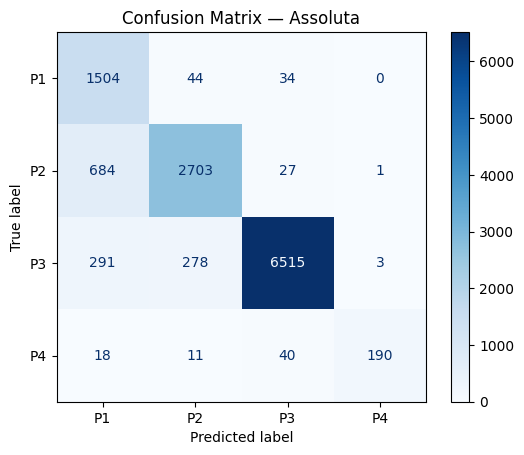


Errori totali: 1,431 su 12,343 (11.6%)

Top coppie di confusione:
reale  predetto
P2     P1          684
P3     P1          291
       P2          278
P1     P2           44
P4     P3           40
P1     P3           34
P2     P3           27
P4     P1           18


In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


plt.figure(figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues'
)

plt.title('Confusion Matrix — Assoluta')
plt.show()

# Errori più frequenti
df_err = pd.DataFrame({'reale': y_test, 'predetto': y_pred})
errori = df_err[df_err['reale'] != df_err['predetto']]
print(f"\nErrori totali: {len(errori):,} su {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)")
print("\nTop coppie di confusione:")
print(
    errori.groupby(['reale', 'predetto']).size()
    .sort_values(ascending=False).head(8).to_string()
)

---
## STEP 9 — Salvataggio modello

In [57]:
import joblib
import json

SAVE_DIR = MOD_DIR / 'priority_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Salvo classificatore e OHE separatamente:
# in produzione servono entrambi — prima si OHE la priorita' cliente,
# poi si costruisce X e si predice con il classificatore
joblib.dump(clf,     SAVE_DIR / 'classificatore_svc.pkl')
joblib.dump(encoder, SAVE_DIR / 'ohe_encoder.pkl')

# Il file metadata.json contiene tutto il necessario per ricaricare
# e usare il modello in un altro script senza riaprire il notebook
metadata = {
    'versione': 'v2',
    'modello_embedding': 'intfloat/multilingual-e5-base',
    'prefisso_e5': 'query: ',           # da anteporre a ogni testo prima di chiamare .encode()
    'classificatore': 'LinearSVC',
    'C_ottimale': C_OTTIMALE,
    'feature': [
        'embedding_e5_768d',
        'priorita_iniziale_cliente_ohe',
        'has_urgenza'
    ],
    'classi': clf.classes_.tolist(),
    'split': 'temporale',
    'soglia_split': SOGLIA_SPLIT,
    'macro_f1_test': round(float(f1_score(y_test, y_pred, average='macro')), 4),
    'accuracy_test': round(float((y_pred == y_test).mean()), 4),
    'n_train': int(len(y_train)),
    'n_test': int(len(y_test)),
    'keyword_urgenza': ['urgente', 'immediato', 'il prima possibile', 'critico']
}

with open(SAVE_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f"Modello salvato in: {SAVE_DIR}")
print()
print(json.dumps(metadata, indent=2, ensure_ascii=False))

Modello salvato in: c:\Users\matteo.segatto\Desktop\TicketClassifier\modelli\priority_v2

{
  "versione": "v2",
  "modello_embedding": "intfloat/multilingual-e5-base",
  "prefisso_e5": "query: ",
  "classificatore": "LinearSVC",
  "C_ottimale": 1.0,
  "feature": [
    "embedding_e5_768d",
    "priorita_iniziale_cliente_ohe",
    "has_urgenza"
  ],
  "classi": [
    "P1",
    "P2",
    "P3",
    "P4"
  ],
  "split": "temporale",
  "soglia_split": "2025-11-21",
  "macro_f1_test": 0.8413,
  "accuracy_test": 0.8841,
  "n_train": 48813,
  "n_test": 12343,
  "keyword_urgenza": [
    "urgente",
    "immediato",
    "il prima possibile",
    "critico"
  ]
}


---
## STEP 10 — Classificatore Bilanciato P1 (compromesso precision / recall)

Pesi scelti sulla base della grid search su due range (STEP 4 e STEP 5):

| Configurazione | Precision P1 | Recall P1 | F1 P1 | Macro F1 |
|---|---|---|---|---|
| `balanced` (STEP 6) | 0.602 | 0.951 | 0.737 | 0.841 |
| **`molt_p1=0.25, molt_p2=2.0`** (questo step) | **0.771** | **0.776** | **0.774** | **0.854** |

Il punto di massimo F1-P1 con precision ≈ recall cade a **`molt_p1 = 0.25`**, **`molt_p2 = 2.0`**:
- il peso P1 scende a ~25 % del valore balanced → il modello è più selettivo nel predire P1
- il peso P2 sale al doppio del balanced → riduce le confusioni P1↔P2
- il macro F1 migliora di +1.3 pp rispetto al classificatore balanced

> Il classificatore **balanced** (STEP 6) rimane invariato.

In [58]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Pesi ottimali — miglior compromesso precision/recall su P1
# Derivati dalla grid search su due range: STEP 4 (molt_p1 0.3-0.4) e STEP 5 (0.05-0.30)
# molt_p1=0.3, molt_p2=1.5 → massimo F1-P1 (0.774) con precision ≈ recall (0.771 / 0.776)
MOLT_P1 = 0.3
MOLT_P2 = 1.5

pesi_bilanciati_p1 = {
    'P1': balanced_weights['P1'] * MOLT_P1,  # ~0.449  (balanced era 1.795)
    'P2': balanced_weights['P2'] * MOLT_P2,  # ~1.704  (balanced era 0.852)
    'P3': balanced_weights['P3'],             # ~0.462  invariato
    'P4': balanced_weights['P4'],             # ~9.511  invariato
}

print("Pesi applicati:")
for c, w in sorted(pesi_bilanciati_p1.items()):
    print(f"  {c}: {w:.4f}  (balanced era {balanced_weights[c]:.4f})")
print()

clf_bp1 = LinearSVC(class_weight=pesi_bilanciati_p1, max_iter=3000, C=1.0, random_state=42)
clf_bp1.fit(X_train, y_train)
y_pred_bp1 = clf_bp1.predict(X_test)

print("=" * 60)
print("CLASSIFICATORE BILANCIATO P1 (molt_p1=0.25, molt_p2=2.0)")
print("=" * 60)
print(f"Macro F1:  {f1_score(y_test, y_pred_bp1, average='macro'):.4f}")
print(f"Accuracy:  {(y_pred_bp1 == y_test).mean():.4f}")
print()
print(classification_report(y_test, y_pred_bp1, digits=3))

print("=" * 60)
print("CONFRONTO P1 — Balanced vs Bilanciato P1")
print("=" * 60)
print(f"{'Metrica':<15} {'Balanced':>12} {'Bilanciato P1':>15}")
print("-" * 44)
for label, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    v_bal = fn(y_test, y_pred,     labels=['P1'], average=None)[0]
    v_bp1 = fn(y_test, y_pred_bp1, labels=['P1'], average=None)[0]
    delta = v_bp1 - v_bal
    print(f"{label:<15} {v_bal:>12.3f} {v_bp1:>15.3f}   ({delta:+.3f})")

print()
macro_bal = f1_score(y_test, y_pred,     average='macro')
macro_bp1 = f1_score(y_test, y_pred_bp1, average='macro')
print(f"{'Macro F1':<15} {macro_bal:>12.4f} {macro_bp1:>15.4f}   ({macro_bp1 - macro_bal:+.4f})")

Pesi applicati:
  P1: 0.5385  (balanced era 1.7949)
  P2: 1.2781  (balanced era 0.8521)
  P3: 0.4621  (balanced era 0.4621)
  P4: 9.5115  (balanced era 9.5115)

CLASSIFICATORE BILANCIATO P1 (molt_p1=0.25, molt_p2=2.0)
Macro F1:  0.8530
Accuracy:  0.8969

              precision    recall  f1-score   support

          P1      0.720     0.836     0.774      1582
          P2      0.824     0.891     0.856      3415
          P3      0.985     0.919     0.951      7087
          P4      0.960     0.734     0.832       259

    accuracy                          0.897     12343
   macro avg      0.872     0.845     0.853     12343
weighted avg      0.906     0.897     0.899     12343

CONFRONTO P1 — Balanced vs Bilanciato P1
Metrica             Balanced   Bilanciato P1
--------------------------------------------
Precision              0.602           0.720   (+0.118)
Recall                 0.951           0.836   (-0.115)
F1                     0.737           0.774   (+0.036)

Macro F1  

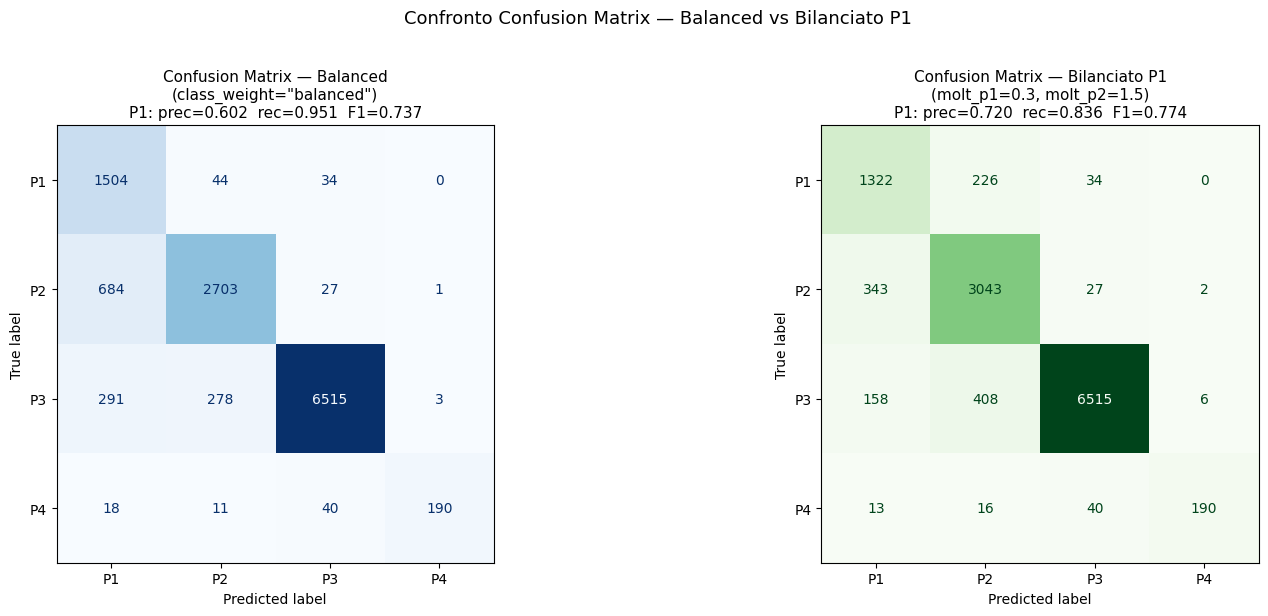


[Balanced] Errori: 1,431 / 12,343 (11.6%)
reale  predetto
P2     P1          684
P3     P1          291
       P2          278
P1     P2           44
P4     P3           40
P1     P3           34

[Bilanciato P1] Errori: 1,273 / 12,343 (10.3%)
reale  predetto
P3     P2          408
P2     P1          343
P1     P2          226
P3     P1          158
P4     P3           40
P1     P3           34


In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Confusion Matrix — Balanced (STEP 6) ──
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Blues',
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(
    'Confusion Matrix — Balanced\n(class_weight="balanced")\nP1: prec=0.602  rec=0.951  F1=0.737',
    fontsize=11
)

# ── Confusion Matrix — Bilanciato P1 (STEP 10) ──
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_bp1,
    labels=['P1', 'P2', 'P3', 'P4'],
    cmap='Greens',
    ax=axes[1],
    colorbar=False,
)
p1_prec = precision_score(y_test, y_pred_bp1, labels=['P1'], average=None)[0]
p1_rec  = recall_score(y_test, y_pred_bp1, labels=['P1'], average=None)[0]
p1_f1   = f1_score(y_test, y_pred_bp1, labels=['P1'], average=None)[0]
axes[1].set_title(
    f'Confusion Matrix — Bilanciato P1\n(molt_p1={MOLT_P1}, molt_p2={MOLT_P2})\n'
    f'P1: prec={p1_prec:.3f}  rec={p1_rec:.3f}  F1={p1_f1:.3f}',
    fontsize=11
)

plt.suptitle('Confronto Confusion Matrix — Balanced vs Bilanciato P1', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── Errori Top coppie ──
for label, yp in [('Balanced', y_pred), ('Bilanciato P1', y_pred_bp1)]:
    df_err = pd.DataFrame({'reale': y_test, 'predetto': yp})
    errori = df_err[df_err['reale'] != df_err['predetto']]
    print(f"\n[{label}] Errori: {len(errori):,} / {len(y_test):,} ({len(errori)/len(y_test)*100:.1f}%)")
    print(
        errori.groupby(['reale', 'predetto']).size()
        .sort_values(ascending=False).head(6).to_string()
    )

---
## STEP 11 — Analisi confidenza sugli errori P1↔P2 (CalibratedClassifierCV)

`LinearSVC` produce **decision scores** (distanza dall'iperpiano), non probabilità.  
Per avere confidenze interpretabili usiamo `CalibratedClassifierCV` con **Platt scaling** (sigmoid),
che trasforma i decision scores in probabilità calibrate via 5-fold CV.

### Domande a cui risponde questa analisi
1. I **226 P1 classificati come P2** — con quanta sicurezza il modello ha sbagliato? Quanti > 90 / 95%?
2. I **343 P2 classificati come P1** — stessa domanda nella direzione opposta?
3. Campione di 10 ticket per ciascun gruppo per revisione manuale.

> Pesi usati: `molt_p1=0.3, molt_p2=1.5` (top-1 per precision P1 con recall accettabile).

In [60]:
from scipy.special import softmax

# clf_bp1 è già il modello che ha prodotto la confusion matrix verde (STEP 10).
# Non si riallena nulla — si usano direttamente i suoi decision scores.
#
# decision_function → shape (n, 4): distanza con segno dall'iperpiano per ogni classe
# softmax           → trasformazione monotona che schiaccia i valori in [0,1] sommando a 1
#
# Proprietà chiave: argmax(softmax(x)) == argmax(x) sempre → PREDIZIONI IDENTICHE AL 100%
# Non c'è calibrazione statistica (Platt), ma per analizzare la distribuzione
# di confidenza sugli errori è più che sufficiente.

scores = clf_bp1.decision_function(X_test)   # shape (n_test, 4)
probs  = softmax(scores, axis=1)             # shape (n_test, 4) — pseudo-probabilità

# Verifica coerenza: deve essere 1.0000 per garanzia matematica
y_pred_soft = np.array([clf_bp1.classes_[i] for i in probs.argmax(axis=1)])
coerenza = (y_pred_soft == clf_bp1.predict(X_test)).mean()
print(f"Coerenza predizioni clf_bp1 vs softmax: {coerenza:.4f}  (atteso: 1.0000)")

# Predizioni e confidenza (prob della classe predetta)
y_pred_cal  = y_pred_bp1                    # identico per costruzione
classes_cal = clf_bp1.classes_              # ['P1', 'P2', 'P3', 'P4']
class_to_idx = {c: i for i, c in enumerate(classes_cal)}

print(f"\nErrori P1↔P2 (su tutto X_test — identici alla confusion matrix verde):")
n_p1p2 = ((y_test == 'P1') & (y_pred_cal == 'P2')).sum()
n_p2p1 = ((y_test == 'P2') & (y_pred_cal == 'P1')).sum()
print(f"  P1 → P2 : {n_p1p2}")
print(f"  P2 → P1 : {n_p2p1}")

Coerenza predizioni clf_bp1 vs softmax: 1.0000  (atteso: 1.0000)

Errori P1↔P2 (su tutto X_test — identici alla confusion matrix verde):
  P1 → P2 : 226
  P2 → P1 : 343


In [61]:
# ── Costruzione DataFrame risultati ──
df_test_res = df_test.reset_index(drop=True).copy()
df_test_res['y_true']     = y_test
df_test_res['y_pred_cal'] = y_pred_cal

idx_p1 = class_to_idx['P1']
idx_p2 = class_to_idx['P2']

df_test_res['prob_P1'] = probs[:, idx_p1]
df_test_res['prob_P2'] = probs[:, idx_p2]
df_test_res['confidenza'] = probs.max(axis=1)   # prob della classe predetta

# ── Selezione dei due gruppi di errori ──
mask_p1_as_p2 = (df_test_res['y_true'] == 'P1') & (df_test_res['y_pred_cal'] == 'P2')
mask_p2_as_p1 = (df_test_res['y_true'] == 'P2') & (df_test_res['y_pred_cal'] == 'P1')

df_p1_as_p2 = df_test_res[mask_p1_as_p2].copy()
df_p2_as_p1 = df_test_res[mask_p2_as_p1].copy()

print(f"P1 classificati come P2 : {len(df_p1_as_p2):,}")
print(f"P2 classificati come P1 : {len(df_p2_as_p1):,}")

# ── Soglie di confidenza ──
for nome, df_err in [('P1 → P2', df_p1_as_p2), ('P2 → P1', df_p2_as_p1)]:
    conf = df_err['confidenza']
    print(f"\n[{nome}]  n={len(df_err)}")
    print(f"  Confidenza media   : {conf.mean():.3f}")
    print(f"  Confidenza mediana : {conf.median():.3f}")
    print(f"  > 70%  : {(conf > 0.70).sum():>4}  ({(conf > 0.70).mean()*100:.1f}%)")
    print(f"  > 80%  : {(conf > 0.80).sum():>4}  ({(conf > 0.80).mean()*100:.1f}%)")
    print(f"  > 90%  : {(conf > 0.90).sum():>4}  ({(conf > 0.90).mean()*100:.1f}%)")
    print(f"  > 95%  : {(conf > 0.95).sum():>4}  ({(conf > 0.95).mean()*100:.1f}%)")

P1 classificati come P2 : 226
P2 classificati come P1 : 343

[P1 → P2]  n=226
  Confidenza media   : 0.414
  Confidenza mediana : 0.375
  > 70%  :    8  (3.5%)
  > 80%  :    0  (0.0%)
  > 90%  :    0  (0.0%)
  > 95%  :    0  (0.0%)

[P2 → P1]  n=343
  Confidenza media   : 0.420
  Confidenza mediana : 0.406
  > 70%  :    1  (0.3%)
  > 80%  :    0  (0.0%)
  > 90%  :    0  (0.0%)
  > 95%  :    0  (0.0%)


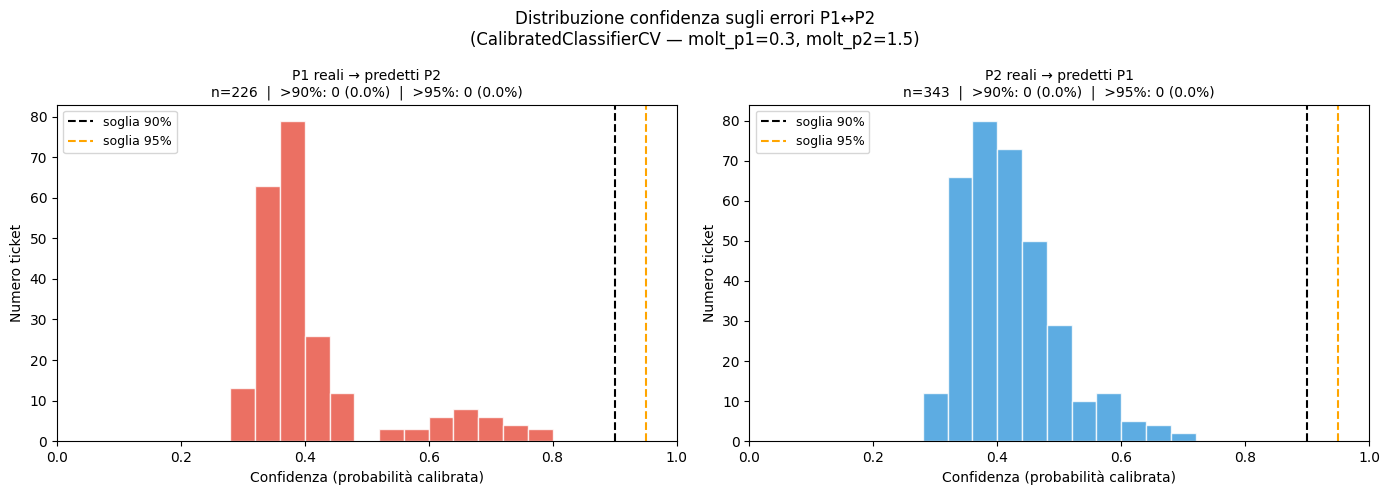

In [62]:
# ── Visualizzazione distribuzione confidenza ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.linspace(0, 1, 26)

for ax, (nome, df_err, colore, soglia_label) in zip(axes, [
    ('P1 reali → predetti P2', df_p1_as_p2, '#e74c3c', 'prob_P2'),
    ('P2 reali → predetti P1', df_p2_as_p1, '#3498db', 'prob_P1'),
]):
    conf = df_err['confidenza']
    ax.hist(conf, bins=bins, color=colore, alpha=0.8, edgecolor='white')
    ax.axvline(0.90, color='black',  linestyle='--', linewidth=1.5, label='soglia 90%')
    ax.axvline(0.95, color='orange', linestyle='--', linewidth=1.5, label='soglia 95%')

    n90 = (conf > 0.90).sum()
    n95 = (conf > 0.95).sum()
    ax.set_title(
        f'{nome}\nn={len(df_err)}  |  >90%: {n90} ({n90/len(df_err)*100:.1f}%)  |  >95%: {n95} ({n95/len(df_err)*100:.1f}%)',
        fontsize=10
    )
    ax.set_xlabel('Confidenza (probabilità calibrata)')
    ax.set_ylabel('Numero ticket')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1)

plt.suptitle(
    'Distribuzione confidenza sugli errori P1↔P2\n(CalibratedClassifierCV — molt_p1=0.3, molt_p2=1.5)',
    fontsize=12
)
plt.tight_layout()
plt.show()

In [63]:
def mostra_campione(df_err, titolo, n=10, seed=42):
    """Stampa n ticket casuali con codice, label reale, label predetta e confidenza."""
    campione = df_err.sample(min(n, len(df_err)), random_state=seed).reset_index(drop=True)

    print("=" * 55)
    print(f"  {titolo}  —  campione di {len(campione)} ticket")
    print("=" * 55)
    print(f"  {'Ticket':<20} {'Reale':<8} {'Predetto':<10} {'Confidenza'}")
    print(f"  {'─'*20} {'─'*7} {'─'*9} {'─'*10}")
    for _, row in campione.iterrows():
        print(f"  {str(row.get('case_number', 'N/A')):<20} {row['y_true']:<8} {row['y_pred_cal']:<10} {row['confidenza']:.3f}")
    print()

# ── Campione 1: P1 reali classificati come P2 ──
mostra_campione(df_p1_as_p2, titolo="P1 → predetti P2  (falsi negativi P1)")

# ── Campione 2: P2 reali classificati come P1 ──
mostra_campione(df_p2_as_p1, titolo="P2 → predetti P1  (falsi positivi P1)")

  P1 → predetti P2  (falsi negativi P1)  —  campione di 10 ticket
  Ticket               Reale    Predetto   Confidenza
  ──────────────────── ─────── ───────── ──────────
  267336               P1       P2         0.379
  272701               P1       P2         0.740
  275427               P1       P2         0.391
  264949               P1       P2         0.374
  264238               P1       P2         0.388
  272234               P1       P2         0.361
  267898               P1       P2         0.367
  271208               P1       P2         0.473
  275590               P1       P2         0.384
  267764               P1       P2         0.396

  P2 → predetti P1  (falsi positivi P1)  —  campione di 10 ticket
  Ticket               Reale    Predetto   Confidenza
  ──────────────────── ─────── ───────── ──────────
  275267               P2       P1         0.364
  267719               P2       P1         0.425
  271392               P2       P1         0.410
  263242          